<a href="https://colab.research.google.com/github/yuki-hogehoge/German-Drugstore-dm-Facial-Serum-Analysis/blob/main/notebooks/dm_serum_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧪 German Drugstore (dm) Serum Data Analysis

## 1. Project Goal & Data Pipeline Setup
- Data Schema Design & Concern Flag Rules (データ設計・肌悩みフラグ定義)
- Scraping & Dataset Construction (197 SKUs Scraped)

## 2. Data Cleaning & Preprocessing
- Selecting Top 30 Reviewed Products
- Manual Data Imputation & Text Normalization (名寄せ・補完)

## 3. Overall Market Trends
- Price vs. Rating Distribution
- Brand Category Comparison: Private Label (PL) vs. National Brand (NB)

## 4. Deep Dive: Active Ingredients & Skin Concerns
- 4.1. Top Ingredient Frequency in Highly Rated Products
- 4.2. Average Rating & Price by Active Ingredient (Correlation Analysis)
- 4.3. "Skin Concern x Active Ingredient" Cross-Analysis (有効性アプローチ)

## 5. Brand Strategy & Best-Value Recommendations
- 5.1. Brand Ranking & Differentiators (Strengths by Concern/Ingredient)
- 5.2. Best Value Picks: Finding High-Rating & Low-Price Serums (コスパ最高商品)

## 1. Project Goal & Data Pipeline Setup
- Data Schema Design & Concern Flag Rules (データ設計・肌悩みフラグ定義)
- Scraping & Dataset Construction (197 SKUs Scraped)

### 肌悩み（skin concern）をどうCSVに保持するか考える

**肌悩みごとにフラグ（0か1）の列を作る**

例：concern_dry, concern_sensitive, concern_acne などの列を作り、該当すれば 1、違えば 0 を入力する（いわゆるワンホットエンコーディング形式）。

メリット: Pythonで「乾燥肌向け商品の平均価格」を計算したいとき、df[df['concern_dry'] == 1]['price_per_100ml'].mean() のように一発で超シンプルに計算できる。

デメリット: CSVの列数が少し増える。

### 実データ収集のためのルール作成（表記揺れ・エラー防止）

Pythonで分析する際、データに入力表記のバラつき（表記揺れ）があると、集集計時に別のデータとして扱われてしまったり、エラーの原因になったりします。
事前に以下の4つのルールを決めておきましょう。

1. 店舗名 (shop)
ルール: すべて小文字の dm または Rossmann に統一する。

2. 小数点・価格表記 (price_eur, price_per_100ml)
ルール: カンマ（,）ではなくピリオド（.）を使用する。

❌ 1,95

⭕ 1.95

※ドイツ語圏のExcelはデフォルトでカンマが少数点になりがちですが、Pythonでは数値として読み込めなくなるため、入力時またはCSV書き出し時に数値フォーマット（ピリオド）へ変換するか、注意して入力します。

3. ブランド名 (brand)
ルール: 大文字・小文字を統一する（例: Balea, Isana, Nivea など）。

❌ balea, BALEA

⭕ Balea

4. 商品タイプ (product_type)
ルール: あらかじめ決めた分類リストから選択して入力する。

## 2. Data Cleaning & Preprocessing
- Selecting Top 30 Reviewed Products
- Manual Data Imputation & Text Normalization (名寄せ・補完)

### スクレイピング
chrome Web Storeで"Web Scraper"をインストール

下記サイトをスクレイピング

https://www.dm.de/pflege-und-parfum/gesichtspflege/serum-und-kur

初期条件のまま179件分の商品データcsv('dm-serum-2026-08-07.csv')を作成(2026/8/7)

取得されたデータの列名（data, data2, data5, data6 など）がWeb Scraperのデフォルトの名前になっているので、以下のコードで先ほど決めたテンプレート（列定義）に合わせて自動整形（クリーニング＆変換）する

In [ ]:
import pandas as pd
import re

# アップロードされた生のCSVを読み込み
github_raw_url = "https://raw.githubusercontent.com/yuki-hogehoge/German-Drugstore-dm-Facial-Serum-Analysis/refs/heads/main/data/dm-serum-2026-08-07.csv"
raw_df = pd.read_csv(github_raw_url)

cleaned_rows = []

for idx, row in raw_df.iterrows():
    # ブランド名と商品名
    brand = str(row['data5']).strip() if pd.notna(row['data5']) else ''
    product = str(row['data']).strip() if pd.notna(row['data']) else ''

    # 価格 (例: "4,95 €" -> 4.95)
    price_str = str(row['data2'])
    price_match = re.search(r'([\d,]+)', price_str)
    price_eur = float(price_match.group(1).replace(',', '.')) if price_match else None

    # レビュー数 (例: "(452)" -> 452)
    review_str = str(row['data6'])
    review_match = re.search(r'\d+', review_str)
    number_of_reviews = int(review_match.group()) if review_match else 0

    # 100mlあたり価格の抽出 (例: "... (165,00 € je 1 l)" -> 100mlあたり 16.50 €)
    # または Grundpreis から計算
    price_per_100ml = None
    volume_ml = None

    data4_str = str(row['data4'])
    # l表記から100mlあたり価格を計算 (例: 1Lあたり 165,00 € -> 100mlあたり 16.50 €)
    per_l_match = re.search(r'([\d,]+)\s*€\s*je\s*1\s*l', data4_str)
    if per_l_match:
        price_per_1l = float(per_l_match.group(1).replace('.', '').replace(',', '.'))
        price_per_100ml = round(price_per_1l / 10, 2)

    # 容量(ml)の抽出 (例: "0,03 l" -> 30 ml)
    vol_match = re.search(r'([\d,]+)\s*l', data4_str)
    if vol_match:
        vol_l = float(vol_match.group(1).replace(',', '.'))
        volume_ml = round(vol_l * 1000)

    # PB判定 (dmのPBブランド: Balea, Balea MED, alverde, SUNDANCE, No Planet B など)
    dm_pb_brands = ['Balea', 'Balea MED', 'alverde NATURKOSMETIK', 'SUNDANCE', 'no planet b']
    private_label = 1 if brand in dm_pb_brands else 0

    cleaned_rows.append({
        'shop': 'dm',
        'brand': brand,
        'product': product,
        'category': 'Serum',
        'product_type': '',  # 手動またはキーワードで設定
        'private_label': private_label,
        'price_eur': price_eur,
        'volume_ml': volume_ml,
        'price_per_100ml': price_per_100ml,
        'rating': None,  # 星評価スコア（画像として取得されているため後ほど確認）
        'number_of_reviews': number_of_reviews,
        'concern_acne': 0,
        'concern_sensitive': 0,
        'concern_dry': 0,
        'concern_oily': 0,
        'concern_anti_aging': 0,
        'concern_dark_spots': 0,
        'concern_redness': 0,
        'concern_dehydrated': 0,
        'active_ingredient': ''
    })

# DataFrameに変換
cleaned_df = pd.DataFrame(cleaned_rows)

# 変換後のデータを確認（先頭5件）
cleaned_df.head()

,shop,brand,product,category,product_type,private_label,price_eur,volume_ml,price_per_100ml,rating,number_of_reviews,concern_acne,concern_sensitive,concern_dry,concern_oily,concern_anti_aging,concern_dark_spots,concern_redness,concern_dehydrated,active_ingredient
0,dm,Balea,"Serum Niacinamide, 30 ml",Serum,,1,4.95,30.0,16.50,None,452,0,0,0,0,0,0,0,0,
1,dm,Balea,"Ampullen Beauty Hyaluron Lifting-Kur (7x1 ml),...",Serum,,1,4.95,7.0,70.71,None,94,0,0,0,0,0,0,0,0,
2,dm,Balea,"Gesichtsserum Vitamin C, 30 ml",Serum,,1,4.95,30.0,16.50,None,380,0,0,0,0,0,0,0,0,
3,dm,Balea,"Serum Beauty Expert Azelain Booster, 30 ml",Serum,,1,5.95,30.0,19.83,None,253,0,0,0,0,0,0,0,0,
4,dm,Transparent Lab,"Serum Pure Glycerine, 50 ml",Serum,,0,13.95,50.0,27.90,None,84,0,0,0,0,0,0,0,0,


自動整形した表はまだ不完全

1. rating（星評価）が None になっている理由
dmの検索一覧ページでは、星評価（★）がテキスト数字（4.5 など）ではなく、星の画像アイコン（SVG画像）の並びとして表示されているため、表面の一覧取得だけでは数値として取れませんでした。

解決策: 商品の個別詳細ページに入れば「4.5 (452)」のように数値テキストが存在しますが、一覧ページから自動で取得するには、ウェブスクレイパー側で少し工夫した設定（画像要素の属性取得など）をするか、詳細ページへの遷移が必要です。

2. concern（肌悩みフラグ 0/1）をどう設定すべきか
商品一覧のタイトル（data 列）だけでは「Niacinamide Serum」といった基本的な名前しか分からず、「乾燥肌向けか」「敏感肌向けか」といった詳細な効能文言が取れていないため、すべて 0 のままになっています。

分析の質に関わるポイント:
197件全件の肌悩みを1つずつ手作業で商品ページを開いて入力するのは、かなりの時間がかかってしまいます。

**💡 今後の進め方**

案①：主要な30〜50商品に絞って、商品ページを見ながら手動入力する（推奨）
やり方: 今回取得した179件の中から、レビュー数が多い人気商品（上位30〜50件）を抽出します。

メリット: 評価スコア（rating）や肌悩み（concern）、成分（active_ingredient）を正しく正確に入力でき、データ品質が最も高くなります。

### レビュー数上位30商品を抽出して作業用CSVを作る

以下のコードを実行すると、レビュー数が多い順に並べ替えて上位30件を抜き出し、ダウンロード用ファイル（dm_serum_top30_working.csv）を作成します。

さらに、商品名（product）から「Niacinamide」「Hyaluron」「Vitamin C」などのキーワードを読み取り、product_type の初期値を仮設定する処理も加えてあります！

In [ ]:
# レビュー数が多い順（降順）に並べ替え
df_sorted = cleaned_df.sort_values(by='number_of_reviews', ascending=False)

# 上位30件を抽出
top30_df = df_sorted.head(30).copy()

# product_type の簡単な自動推測（手動修正しやすくするための補助）
def guess_product_type(name):
    name_lower = str(name).lower()
    if 'niacinamide' in name_lower:
        return 'Niacinamide Serum'
    elif 'vitamin c' in name_lower:
        return 'Vitamin C Serum'
    elif 'hyaluron' in name_lower:
        return 'Hyaluron Serum'
    elif 'retinol' in name_lower:
        return 'Retinol Serum'
    elif 'peeling' in name_lower or 'aha' in name_lower or 'bha' in name_lower or 'azelain' in name_lower:
        return 'Peeling / Acid Serum'
    else:
        return 'Other Serum'

top30_df['product_type'] = top30_df['product'].apply(guess_product_type)

# Save the DataFrame to CSV before downloading
top30_df.to_csv('dm_serum_top30_working.csv', index=False, encoding='utf-8-sig')

from google.colab import files

# 作業用csvファイルをローカルPCへ直接ダウンロード
files.download('dm_serum_top30_working.csv')

print("上位30件の抽出が完了しました！")
print("\n--- 上位5商品のプレビュー ---")
top30_df[['brand', 'product', 'price_eur', 'price_per_100ml', 'number_of_reviews', 'product_type']].head()

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

上位30件の抽出が完了しました！

--- 上位5商品のプレビュー ---


,brand,product,price_eur,price_per_100ml,number_of_reviews,product_type
57,L'ORÉAL PARiS,Anti-Aging Gesichtsserum Le Duo mit Kollagen.....,24.95,83.17,5406,Other Serum
150,NIVEA,"Serum Intensiv Cellular Luminous 630 Anti..., ...",28.45,94.83,3379,Other Serum
49,Mixa,"Serum Anti-Hautstress, 30 ml",9.95,33.17,2862,Other Serum
71,L'ORÉAL PARiS REVITALIFT,Serum Revitalift Clinical Vitamin C & Vitamin ...,19.95,66.50,2269,Vitamin C Serum
27,Garnier Skin Active,"Serum Glow Booster, Vitamin C Anti-Dunkle-Flec...",11.95,39.83,1228,Vitamin C Serum


### 手動入力によるデータ補完

'dm_serum_top30_working.csv'を"skincare_dataset"スプレッドシートへ貼った。
手動でratig, product_typeとconcernを入力し、csvで出力

メモ

・しわ改善はAnti Agingに分類

出力ファイル名："02_clean_data/skincare_dataset_dm_serum_top30.csv"



In [ ]:
import pandas as pd
import numpy as np

# CSVファイルを読み込み（文字化け防止のため encoding='utf-8-sig' を指定）
file_name = 'https://raw.githubusercontent.com/yuki-hogehoge/German-Drugstore-dm-Facial-Serum-Analysis/refs/heads/main/data/skincare_dataset_dm_serum_top30.csv'
df_30 = pd.read_csv(file_name, encoding='utf-8-sig')

# 1. データの基本情報を確認
print(f"--- データの件数: {len(df_30)} 件 ---")
print("\n--- 各列の欠損値（空欄）の数 ---")
print(df_30.isnull().sum())

# 2. 先頭5件を表示
df_30.head()

--- データの件数: 30 件 ---

--- 各列の欠損値（空欄）の数 ---
shop                  0
brand                 0
product               0
category              0
product_type          0
private_label         0
price_eur             0
volume_ml             0
price_per_100ml       0
rating                0
number_of_reviews     0
concern_acne          0
concern_sensitive     0
concern_dry           0
concern_oily          0
concern_anti_aging    0
concern_dark_spots    0
concern_redness       0
concern_dehydrated    0
active_ingredient     0
Unnamed: 20           0
dtype: int64


,shop,brand,product,category,product_type,private_label,price_eur,volume_ml,price_per_100ml,rating,...,concern_acne,concern_sensitive,concern_dry,concern_oily,concern_anti_aging,concern_dark_spots,concern_redness,concern_dehydrated,active_ingredient,Unnamed: 20
0,dm,L'ORÉAL PARiS,Anti-Aging Gesichtsserum Le Duo mit Kollagen.....,Serum,Anti-Aging / Retinol Serum,0,24.95,30,83.17,4.7,...,0,0,0,0,1,1,0,0,"Kollagen-AS, Vitamin B3, Vitamin Cg",商品ページを開く
1,dm,NIVEA,"Serum Intensiv Cellular Luminous 630 Anti..., ...",Serum,Other Serum,0,28.45,30,94.83,4.5,...,0,0,0,0,0,1,0,0,"LUMINOUS630, Thiamidol",商品ページを開く
2,dm,Mixa,"Serum Anti-Hautstress, 30 ml",Serum,Barrier / Soothing Serum,0,9.95,30,33.17,4.8,...,0,1,0,0,0,0,1,0,"Panthenol, natürlichem Bisabolol",商品ページを開く
3,dm,L'ORÉAL PARiS REVITALIFT,Serum Revitalift Clinical Vitamin C & Vitamin ...,Serum,Vitamin C Serum,0,19.95,30,66.50,4.7,...,0,1,0,0,1,0,0,0,"Vitamin C, Vitamin E, Salicylsäure",商品ページを開く
4,dm,Garnier Skin Active,"Serum Glow Booster, Vitamin C Anti-Dunkle-Flec...",Serum,Vitamin C Serum,0,11.95,30,39.83,4.5,...,0,0,1,0,0,1,0,0,"Niacinamid, Vitamin C, Salicylsäure, Melasyl",商品ページを開く


## 3. Overall Market Trends

- Price vs. Rating Distribution
- Brand Category Comparison: Private Label (PL) vs. National Brand (NB)

### 集計＆グラフ描画コードを実行



=== 肌悩み（concern）別 集計表 ===
       肌悩み  該当商品数  100mlあたり平均価格(€)  平均評価(rating)  平均レビュー数
      acne      2            39.84          4.45    722.5
 sensitive      7            57.20          4.51   1213.1
       dry      8            36.18          4.44    526.0
      oily      1            16.50          4.00    452.0
anti_aging     21            54.47          4.50    860.0
dark_spots     12            59.00          4.51   1275.0
   redness      3            28.72          4.30   1234.0
dehydrated      0             0.00          0.00      0.0




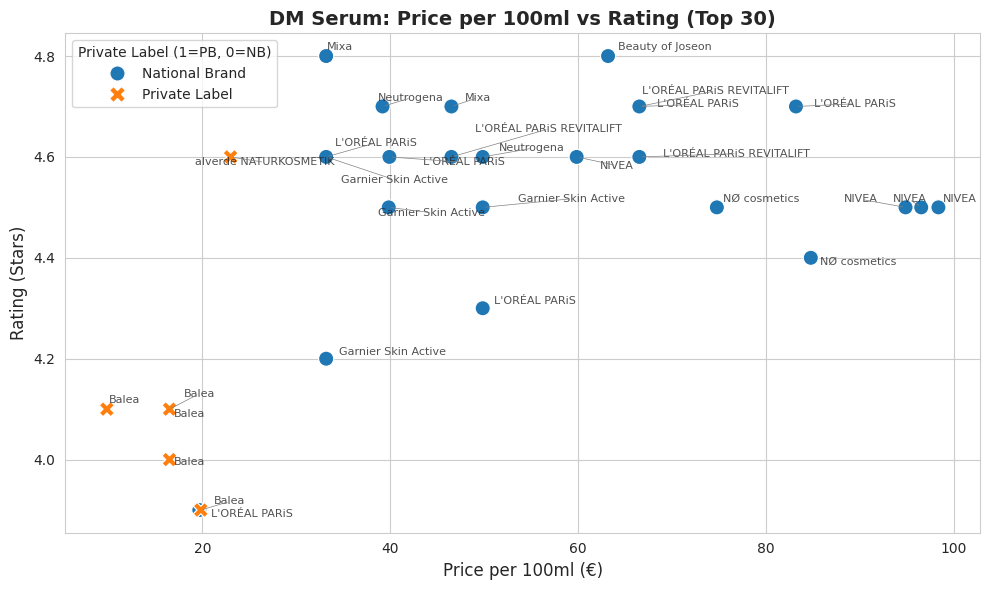

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# adjustTextをインストール（もしインストールされていなければ）
!pip install adjustText
from adjustText import adjust_text

# 1. データの読み込み
##file_name = 'https://github.com/yuki-hogehoge/German-Drugstore-dm-Facial-Serum-Analysis/blob/main/data/skincare_dataset_dm_serum_top30.csv'
df = pd.read_csv(file_name, encoding='utf-8-sig')

# --- 【分析1】肌悩み（concern）ごとの平均価格・平均評価スコアの集計 ---
concern_cols = [c for c in df.columns if c.startswith('concern_')]

summary_list = []
for col in concern_cols:
    # 該当する肌悩みフラグが 1 の商品を抽出
    subset = df[df[col] == 1]
    concern_name = col.replace('concern_', '')

    summary_list.append({
        '肌悩み': concern_name,
        '該当商品数': len(subset),
        '100mlあたり平均価格(€)': round(subset['price_per_100ml'].mean(), 2) if len(subset) > 0 else 0,
        '平均評価(rating)': round(subset['rating'].mean(), 2) if len(subset) > 0 else 0,
        '平均レビュー数': round(subset['number_of_reviews'].mean(), 1) if len(subset) > 0 else 0
    })

summary_df = pd.DataFrame(summary_list)
print("=== 肌悩み（concern）別 集計表 ===")
print(summary_df.to_string(index=False))
print("\n" + "="*40 + "\n")


# --- 【分析2】価格 vs 評価 の散布図（Scatter Plot）作成 ---
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# Private Label (PB=1, NB=0) で色分けしてプロット
# 凡例表示のために'private_label'列を文字列に変換
df['private_label_text'] = df['private_label'].map({0: 'National Brand', 1: 'Private Label'})

sns.scatterplot(
    data=df,
    x='price_per_100ml',
    y='rating',
    hue='private_label_text', # 新しい列をhueに使用
    style='private_label_text', # 新しい列をstyleに使用
    s=120, # マーカーの大きさ
    palette={'National Brand': '#1f77b4', 'Private Label': '#ff7f0e'}, # カラーマッピングを文字列に更新
    markers={'National Brand': 'o', 'Private Label': 'X'} # マーカーマッピングを文字列に更新
)

# 各点にブランド名/商品名を注記（ラベル表示）
texts = []
for i, row in df.iterrows():
    texts.append(plt.text(
        row['price_per_100ml'], # X座標はそのまま
        row['rating'],       # Y座標はそのまま
        f"{row['brand']}",
        fontsize=8,
        alpha=0.8
    ))

# adjust_text を使用してラベルの重なりを解消
adjust_text(texts,
            arrowprops=dict(arrowstyle='-', color='gray', lw=0.5), # 矢印のスタイル
            expand_points=(1.5, 1.5), # ポイントからの膨張率
            force_points=0.2, # ポイントへの力の強さ
            force_text=0.5) # テキスト間の力の強さ

plt.title('DM Serum: Price per 100ml vs Rating (Top 30)', fontsize=14, fontweight='bold')
plt.xlabel('Price per 100ml (€)', fontsize=12)
plt.ylabel('Rating (Stars)', fontsize=12)
# plt.legend() はseabornが自動で生成するため削除（または後でカスタマイズ）
# カスタムタイトルを設定したい場合は、以下のようにaxesオブジェクトからlegendを取得して設定します
ax = plt.gca()
legend = ax.legend()
if legend:
    legend.set_title('Private Label (1=PB, 0=NB)')

# グラフを表示
plt.tight_layout()
plt.show()

1. 集計表の考察

anti_aging が最多（21件） ：

分析: シワ改善やハリ（Falten, Strahlkraft など）を包含して分類した判断は非常に妥当です。ドイツのドラッグストア（dm）において、セラムカテゴリの主要購買層や開発ターゲットが「年齢肌ケア」に大きくシフトしている市場構造が数値で裏付けられました。

高価格帯エリア（dark_spots 59.00€ / sensitive 57.20€ / anti_aging 54.47€）：

分析: ビタミンC・ナイアシンアミド高濃度配合の美白系（dark_spots）や、無添加・バリア機能を訴求する敏感肌用（sensitive）、エイジングケア系は原価や成分訴求の観点から高価格に設定しやすい（＝プレミアム価格帯）という市場の傾向が綺麗に出ています。

2. 散布図の考察
「高価格＝高評価」はゆるやか／最高評価は中価格帯：

分析: 高価格帯商品は一定のクオリティが担保されているため極端な低評価（★3以下など）が出にくい一方、「最も評価（★）が高い商品」は中価格帯（100mlあたり20〜40€付近）に集まっている点（＝いわゆる「コスパ最強ゾーン」）を捉えられたのは非常に素晴らしい発見です！

PBは低価格だが評価は控えめ：

分析: BaleaなどのPB（プライベートブランド）は100mlあたり価格が圧倒的に安く試しやすいが、高評価には至らない。

### Brand Category Comparison: Private Label (PL) vs. National Brand (NB)

今回は以下の2つの深掘り分析を行います。

- PB (Balea等) vs NB (L'Oréal等) の価格・評価の分布比較（箱ひげ図 / Boxplot）


- 評価スコア（rating）上位商品の特徴抽出

★4.6以上の「高評価セラム」に共通する成分や肌悩みフラグを抜き出します。

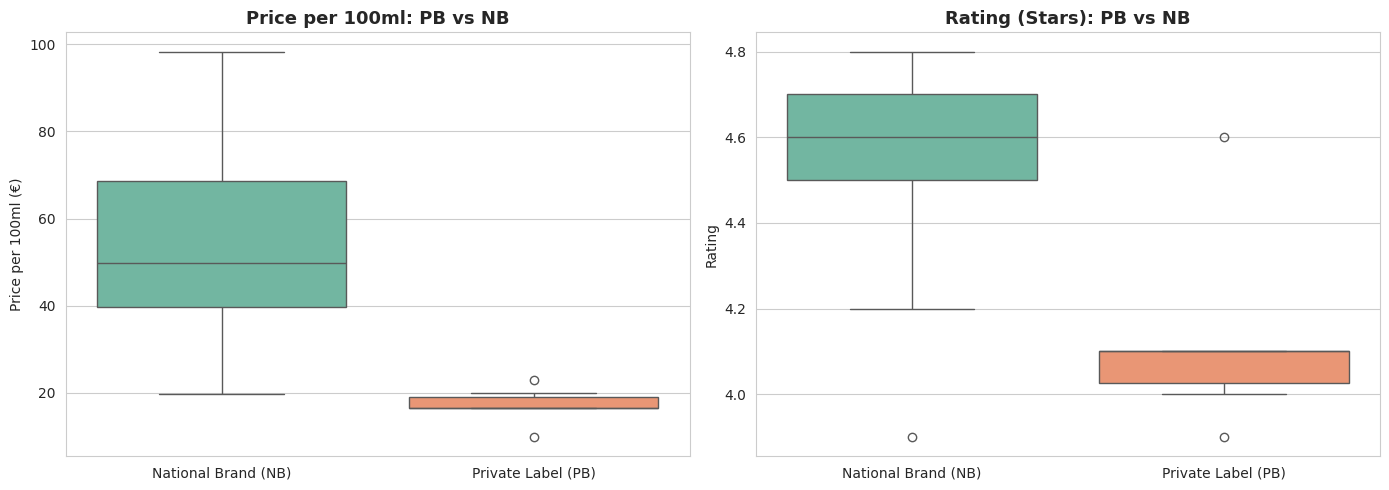

=== ★4.6以上の高評価セラム（一部抜粋） ===
                   brand                                                    product  price_eur  price_per_100ml  rating  number_of_reviews               product_type
           L'ORÉAL PARiS     Anti-Aging Gesichtsserum Le Duo mit Kollagen..., 30 ml      24.95            83.17     4.7               5406 Anti-Aging / Retinol Serum
                    Mixa                               Serum Anti-Hautstress, 30 ml       9.95            33.17     4.8               2862   Barrier / Soothing Serum
L'ORÉAL PARiS REVITALIFT     Serum Revitalift Clinical Vitamin C & Vitamin E, 30 ml      19.95            66.50     4.7               2269            Vitamin C Serum
                    Mixa                Serum Anti-Unreinheiten, Niacinamide, 30 ml      13.95            46.50     4.7               1029          Niacinamide Serum
           L'ORÉAL PARiS      Serum Midnight Age Perfect Zell-Renaissance..., 30 ml      19.95            66.50     4.7               1003 Ant

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. データの読み込み
##file_name = 'https://github.com/yuki-hogehoge/German-Drugstore-dm-Facial-Serum-Analysis/blob/main/data/skincare_dataset_dm_serum_top30.csv'
df = pd.read_csv(file_name, encoding='utf-8-sig')

# --- 【分析1】PB vs NB の価格・評価の比較（Boxplot） ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.set_style("whitegrid")

# PB/NBの表示ラベル作成
df['brand_type'] = df['private_label'].map({1: 'Private Label (PB)', 0: 'National Brand (NB)'})

# ① 100mlあたり価格の比較
sns.boxplot(data=df, x='brand_type', y='price_per_100ml', ax=axes[0], hue='brand_type', palette='Set2', legend=False)
axes[0].set_title('Price per 100ml: PB vs NB', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Price per 100ml (€)')
axes[0].set_xlabel('')

# ② 評価スコア（rating）の比較
sns.boxplot(data=df, x='brand_type', y='rating', ax=axes[1], hue='brand_type', palette='Set2', legend=False)
axes[1].set_title('Rating (Stars): PB vs NB', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Rating')
axes[1].set_xlabel('')

plt.tight_layout()
plt.show()


# --- 【分析2】高評価グループ（rating >= 4.6）の特徴抽出 ---
high_rating_df = df[df['rating'] >= 4.6]

print("=== ★4.6以上の高評価セラム（一部抜粋） ===")
cols_to_show = ['brand', 'product', 'price_eur', 'price_per_100ml', 'rating', 'number_of_reviews', 'product_type']
print(high_rating_df[cols_to_show].to_string(index=False))

print("\n" + "="*50)
print(f"全30件中、高評価（★4.6以上）の商品数: {len(high_rating_df)} 件")
print(f"高評価商品のうちPBの割合: {round((high_rating_df['private_label'] == 1).mean() * 100, 1)}%")
print("="*50)

In [ ]:
print("=== Private Label (PB) の中央値 ===")
pb_df = df[df['private_label'] == 1]

median_price_pb = pb_df['price_per_100ml'].median()
median_rating_pb = pb_df['rating'].median()

print(f"100mlあたり価格の中央値 (PB): {median_price_pb:.2f} €")
print(f"評価スコアの中央値 (PB): {median_rating_pb:.2f}")

print("\n=== National Brand (NB) の中央値 (参考) ===")
nb_df = df[df['private_label'] == 0]
median_price_nb = nb_df['price_per_100ml'].median()
median_rating_nb = nb_df['rating'].median()
print(f"100mlあたり価格の中央値 (NB): {median_price_nb:.2f} €")
print(f"評価スコアの中央値 (NB): {median_rating_nb:.2f}")

=== Private Label (PB) の中央値 ===
100mlあたり価格の中央値 (PB): 16.50 €
評価スコアの中央値 (PB): 4.10

=== National Brand (NB) の中央値 (参考) ===
100mlあたり価格の中央値 (NB): 49.83 €
評価スコアの中央値 (NB): 4.60


## 4. Deep Dive: Active Ingredients & Skin Concerns
- 4.1. Top Ingredient Frequency in Highly Rated Products
- 4.2. Average Rating & Price by Active Ingredient (Correlation Analysis)
- 4.3. "Skin Concern x Active Ingredient" Cross-Analysis (有効性アプローチ)

### 4.1. Top Ingredient Frequency in Highly Rated Products

In [ ]:
from collections import Counter
import re

# high_rating_df は前のセルで作成済み
# high_rating_df = df[df['rating'] >= 4.6]

# 検出したい主要な成分キーワードのリスト (小文字で正規化)
# ユーザーが例として挙げたものや一般的な成分を含む
specific_ingredients_to_count = [
    'niacinamid', 'hyaluronsäure', 'vitamin c', 'retinol', 'kollagen',
    'glycerin', 'salicylsäure', 'panthenol', 'vitamin e', 'q10',
    'bisabolol', 'aloe vera', 'ginseng', 'retinal' # RetinalもRetinol関連として追加
]

# 各成分の出現回数をカウントするためのCounter
ingredient_keyword_counts = Counter()

# high_rating_dfの各行をループ
for _, row in high_rating_df.iterrows():
    active_ingredient_str = str(row['active_ingredient']).lower()
    if not active_ingredient_str or active_ingredient_str == 'nan':
        continue # 空白またはNaNの場合はスキップ

    # 各商品で、定義したキーワードがいくつ含まれているかカウント
    for keyword in specific_ingredients_to_count:
        # 単語の境界を考慮して、キーワードが何回出現するかを数える
        # re.escape はキーワードが正規表現の特殊文字を含む場合にエスケープするために使用
        matches = re.findall(r'\b' + re.escape(keyword) + r'\b', active_ingredient_str)
        if matches:
            ingredient_keyword_counts[keyword] += len(matches)

print("=== 高評価商品の主要成分キーワード出現頻度（複数カウント対応） ===")
# 出現頻度の高い順に表示
for ingredient, count in ingredient_keyword_counts.most_common():
    print(f"{ingredient}: {count}")

=== 高評価商品の主要成分キーワード出現頻度（複数カウント対応） ===
vitamin c: 4
hyaluronsäure: 4
kollagen: 2
salicylsäure: 2
vitamin e: 2
niacinamid: 2
retinol: 2
panthenol: 1
bisabolol: 1
glycerin: 1
q10: 1
aloe vera: 1
ginseng: 1
retinal: 1


### 4.2. Average Rating & Price by Active Ingredient (Correlation Analysis)

In [ ]:
import re
import pandas as pd

# 検出したい主要な成分キーワードのリスト (小文字で正規化)
# 前のセルで定義したリストを再利用
specific_ingredients_to_count = [
    'niacinamid', 'hyaluronsäure', 'vitamin c', 'retinol', 'kollagen',
    'glycerin', 'salicylsäure', 'panthenol', 'vitamin e', 'q10',
    'bisabolol', 'aloe vera', 'ginseng', 'retinal'
]

ingredient_avg_ratings = []

# df (全商品データ) を使用して、各成分が含まれる商品の平均評価を計算
for keyword in specific_ingredients_to_count:
    # 正規表現で単語の境界を考慮してキーワードを検索
    # active_ingredient列がNoneやNaNの場合も考慮し、strに変換
    mask = df['active_ingredient'].astype(str).str.contains(r'\b' + re.escape(keyword) + r'\b', case=False, na=False)

    # 該当する商品があれば平均評価を計算
    if mask.any():
        avg_rating = df[mask]['rating'].mean()
        ingredient_avg_ratings.append({'成分': keyword, '平均評価': round(avg_rating, 2)})

# 結果をDataFrameに変換し、平均評価の高い順にソート
df_ingredient_avg_ratings = pd.DataFrame(ingredient_avg_ratings)
df_ingredient_avg_ratings = df_ingredient_avg_ratings.sort_values(by='平均評価', ascending=False).reset_index(drop=True)

print("=== 各主要成分が含まれる製品の平均評価 ===")
display(df_ingredient_avg_ratings)

# 全商品の平均評価も表示して比較
overall_avg_rating = df['rating'].mean()
print(f"\n全製品の平均評価: {overall_avg_rating:.2f}")

=== 各主要成分が含まれる製品の平均評価 ===


,成分,平均評価
0,retinal,4.80
1,panthenol,4.80
2,bisabolol,4.80
3,ginseng,4.80
4,vitamin e,4.70
5,salicylsäure,4.63
6,glycerin,4.60
7,kollagen,4.60
8,aloe vera,4.60
9,q10,4.55



全製品の平均評価: 4.46


**成分別平均評価の可視化**

各主要成分が含まれる製品の平均評価を棒グラフで可視化します。全体平均評価を比較線として表示することで、どの成分が高評価の製品と相関が強いか、あるいは弱いかを直感的に理解できます。

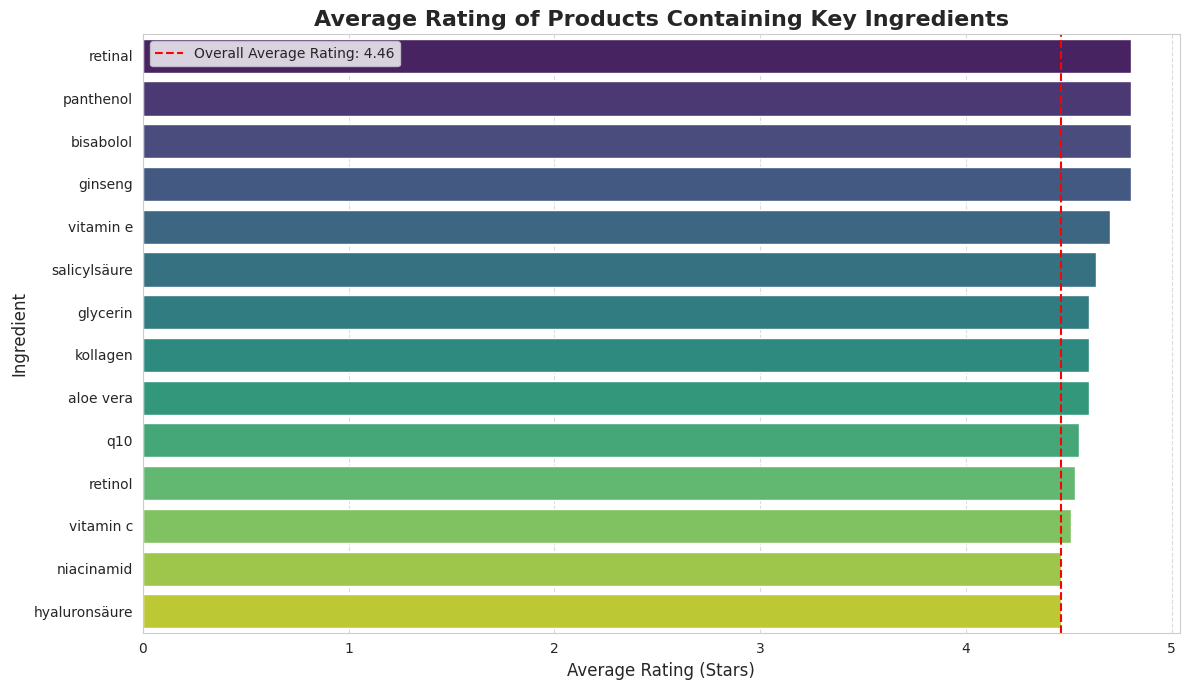

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))
sns.barplot(x='平均評価', y='成分', data=df_ingredient_avg_ratings, palette='viridis', hue='成分', legend=False)

# Overall average rating as a vertical line
plt.axvline(x=overall_avg_rating, color='red', linestyle='--', label=f'Overall Average Rating: {overall_avg_rating:.2f}')

plt.title('Average Rating of Products Containing Key Ingredients', fontsize=16, fontweight='bold')
plt.xlabel('Average Rating (Stars)', fontsize=12)
plt.ylabel('Ingredient', fontsize=12)
plt.legend()
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**成分の平均価格と平均評価の散布図**

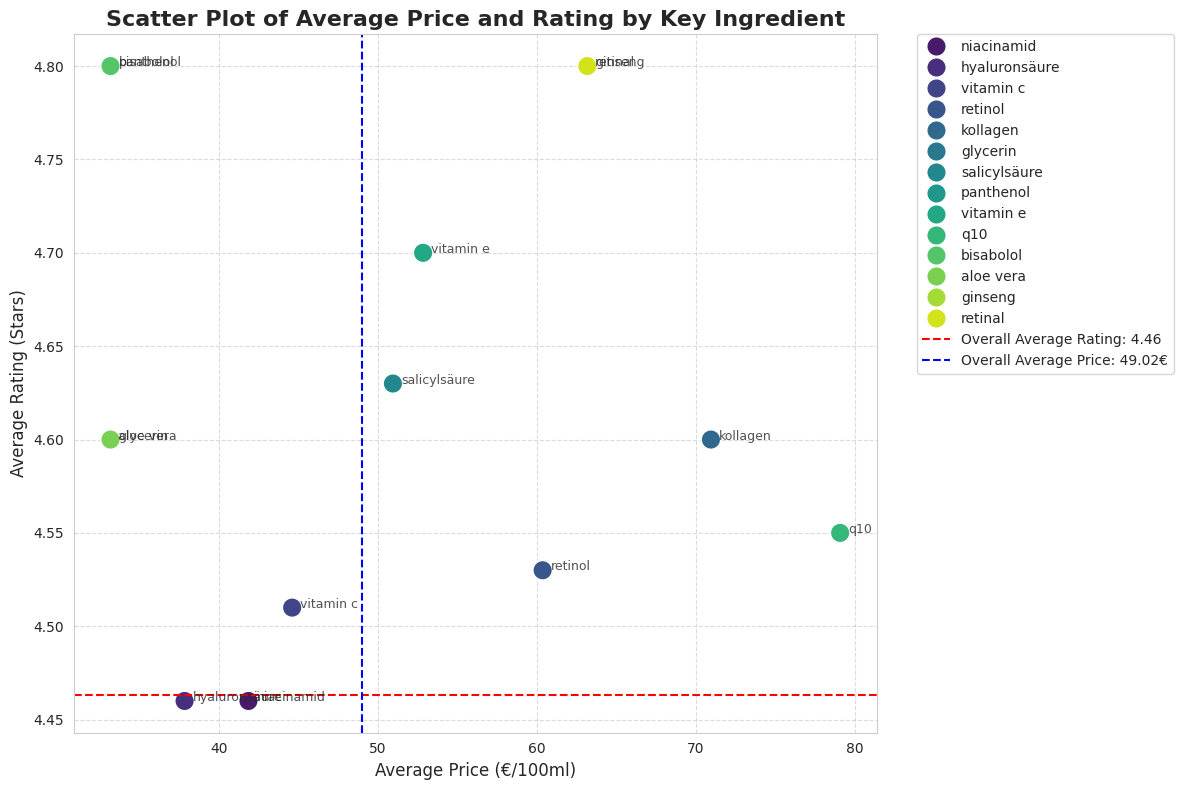

In [ ]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the DataFrame, assuming it's the same as in previous cells that define 'df'
# Using absolute path for robustness against CWD changes
##file_name = 'https://github.com/yuki-hogehoge/German-Drugstore-dm-Facial-Serum-Analysis/blob/main/data/skincare_dataset_dm_serum_top30.csv'
df = pd.read_csv(file_name, encoding='utf-8-sig')

# 検出したい主要な成分キーワードのリスト (小文字で正規化)
# 前のセルで定義したリストを再利用
specific_ingredients_to_count = [
    'niacinamid', 'hyaluronsäure', 'vitamin c', 'retinol', 'kollagen',
    'glycerin', 'salicylsäure', 'panthenol', 'vitamin e', 'q10',
    'bisabolol', 'aloe vera', 'ginseng', 'retinal'
]

# 各成分の平均価格と平均評価を格納するためのリスト
ingredient_stats = []

for keyword in specific_ingredients_to_count:
    # 正規表現で単語の境界を考慮してキーワードを検索
    mask = df['active_ingredient'].astype(str).str.contains(r'\b' + re.escape(keyword) + r'\b', case=False, na=False)

    if mask.any():
        subset = df[mask]
        avg_rating = subset['rating'].mean()
        avg_price_per_100ml = subset['price_per_100ml'].mean()
        ingredient_stats.append({
            'Ingredient': keyword,
            'Average Rating': round(avg_rating, 2),
            'Average Price (€/100ml)': round(avg_price_per_100ml, 2)
        })

df_ingredient_stats = pd.DataFrame(ingredient_stats)

# 全商品の平均評価と平均価格を計算
overall_avg_rating = df['rating'].mean()
overall_avg_price = df['price_per_100ml'].mean()

plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=df_ingredient_stats,
    x='Average Price (€/100ml)',
    y='Average Rating',
    hue='Ingredient', # 各成分を色分け
    s=200, # マーカーサイズ
    palette='viridis', # カラーパレット
    legend='full' # 凡例を表示
)

# 各点に成分名を注記
for i, row in df_ingredient_stats.iterrows():
    plt.text(
        row['Average Price (€/100ml)'] + 0.5, # X座標を少しずらして見やすく
        row['Average Rating'],
        row['Ingredient'],
        fontsize=9,
        alpha=0.8
    )

# 全商品の平均評価を水平線で表示
plt.axhline(y=overall_avg_rating, color='red', linestyle='--', label=f'Overall Average Rating: {overall_avg_rating:.2f}')
# 全商品の平均価格を垂直線で表示
plt.axvline(x=overall_avg_price, color='blue', linestyle='--', label=f'Overall Average Price: {overall_avg_price:.2f}€')

plt.title('Scatter Plot of Average Price and Rating by Key Ingredient', fontsize=16, fontweight='bold')
plt.xlabel('Average Price (€/100ml)', fontsize=12)
plt.ylabel('Average Rating (Stars)', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.) # 凡例をグラフの外に配置
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**成分の平均価格と平均評価の相関係数**

各成分が含まれる製品の平均価格と平均評価の間の相関係数を計算します。相関係数は、2つの変数がどの程度一緒に動くかを示す指標で、-1から1の範囲で表されます。

*   1に近いほど正の相関が強く、平均価格が高いほど平均評価も高い傾向にあります。
*   -1に近いほど負の相関が強く、平均価格が高いほど平均評価が低い傾向にあります。
*   0に近いほど相関は弱く、平均価格と平均評価の間に明確な関係がないことを示します。

In [ ]:
# 平均評価と平均価格の相関係数を計算
correlation = df_ingredient_stats['Average Rating'].corr(df_ingredient_stats['Average Price (€/100ml)'])

print(f"成分ごとの平均評価と平均価格の相関係数: {correlation:.2f}")

if correlation > 0.5:
    print("\n強い正の相関があります。平均価格が高い成分ほど、平均評価も高い傾向にあります。")
elif correlation > 0.2:
    print("\n中程度の正の相関があります。平均価格が高い成分ほど、平均評価もやや高い傾向にあります。")
elif correlation < -0.5:
    print("\n強い負の相関があります。平均価格が高い成分ほど、平均評価が低い傾向にあります。")
elif correlation < -0.2:
    print("\n中程度の負の相関があります。平均価格が高い成分ほど、平均評価がやや低い傾向にあります。")
else:
    print("\n相関は弱いか、ほとんどありません。平均価格と平均評価の間に明確な線形関係は見られません。")

成分ごとの平均評価と平均価格の相関係数: 0.00

相関は弱いか、ほとんどありません。平均価格と平均評価の間に明確な線形関係は見られません。


### 4.3. "Skin Concern x Active Ingredient" Cross-Analysis

指定した肌悩み（例: anti_aging, dark_spots, dry 等）ごとに「配合されている主要成分」「その成分を含む商品の平均評価」「商品数」のランキングを出力・可視化できます。


### Active Ingredient Analysis by Skin Concern

--- Concern: acne (Number of products: 2) ---


,Ingredient,Average Rating,Product Count
0,salicylsäure,4.70,1
1,niacinamid,4.45,2


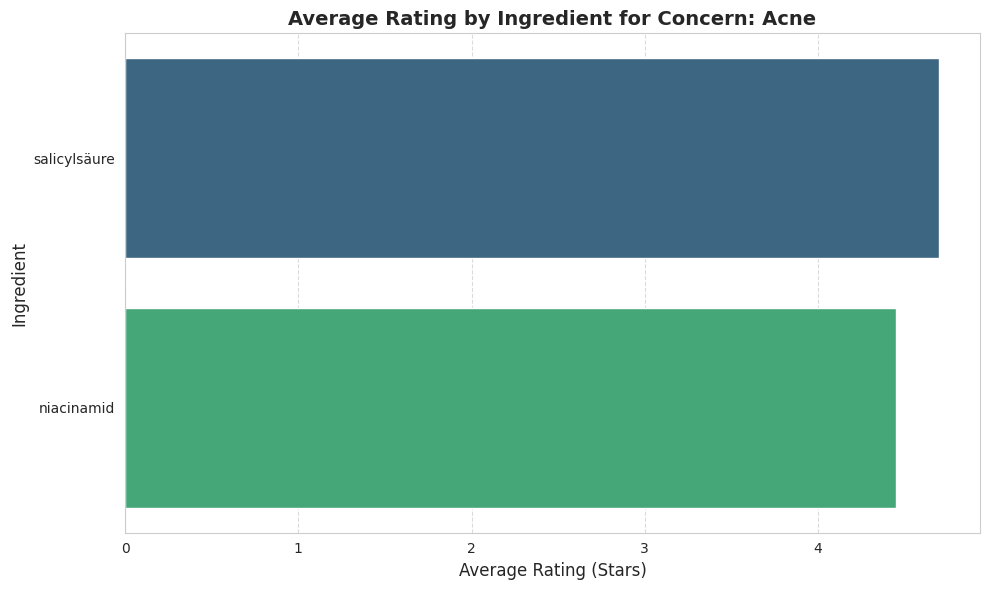



--- Concern: sensitive (Number of products: 7) ---


,Ingredient,Average Rating,Product Count
0,bisabolol,4.80,1
1,panthenol,4.80,1
2,vitamin e,4.70,1
3,salicylsäure,4.70,1
4,vitamin c,4.65,2
5,glycerin,4.60,1
6,kollagen,4.55,2
7,retinol,4.40,1


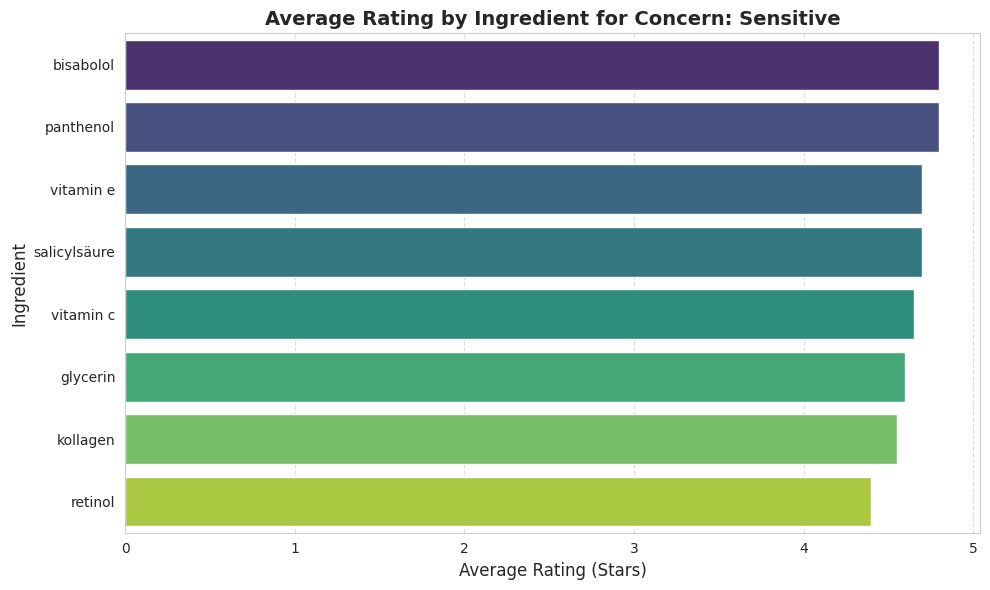



--- Concern: dry (Number of products: 8) ---


,Ingredient,Average Rating,Product Count
0,vitamin e,4.7,1
1,retinol,4.6,1
2,aloe vera,4.6,1
3,vitamin c,4.5,1
4,hyaluronsäure,4.5,4
5,niacinamid,4.5,1
6,salicylsäure,4.5,1


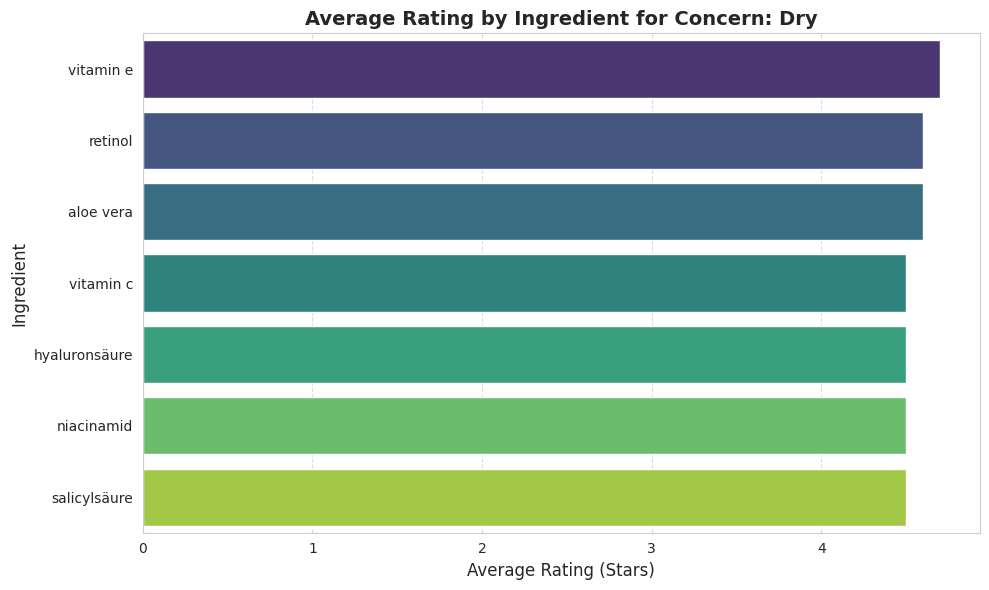



--- Concern: oily (Number of products: 1) ---
  No major ingredients found.

--- Concern: anti_aging (Number of products: 21) ---


,Ingredient,Average Rating,Product Count
0,ginseng,4.80,1
1,retinal,4.80,1
2,salicylsäure,4.70,1
3,vitamin e,4.70,2
4,kollagen,4.60,3
5,vitamin c,4.60,5
6,glycerin,4.60,1
7,q10,4.55,2
8,retinol,4.53,3
9,hyaluronsäure,4.50,5


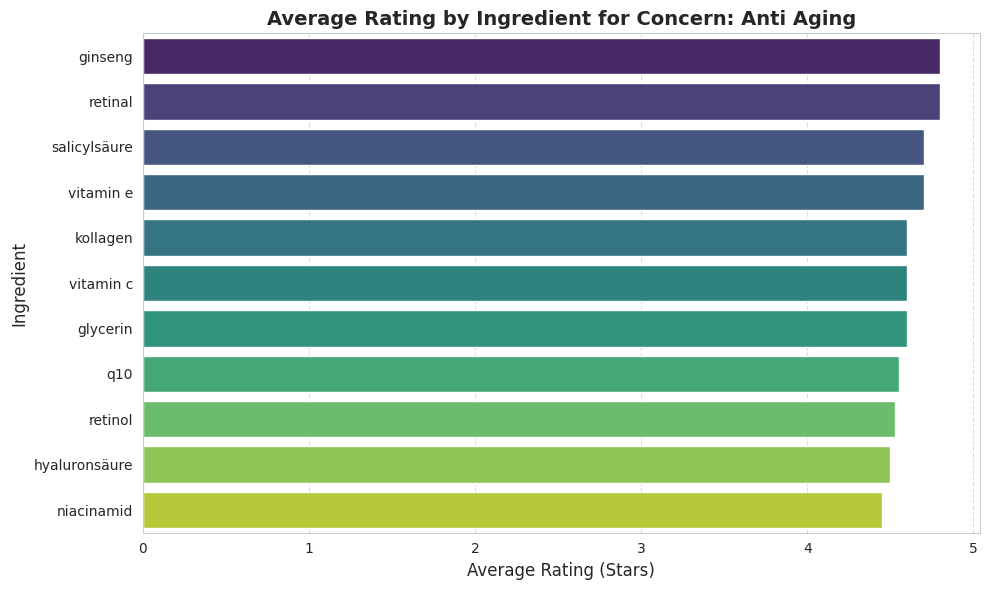



--- Concern: dark_spots (Number of products: 12) ---


,Ingredient,Average Rating,Product Count
0,kollagen,4.60,2
1,retinol,4.60,1
2,salicylsäure,4.60,2
3,hyaluronsäure,4.57,3
4,niacinamid,4.53,4
5,vitamin c,4.46,5


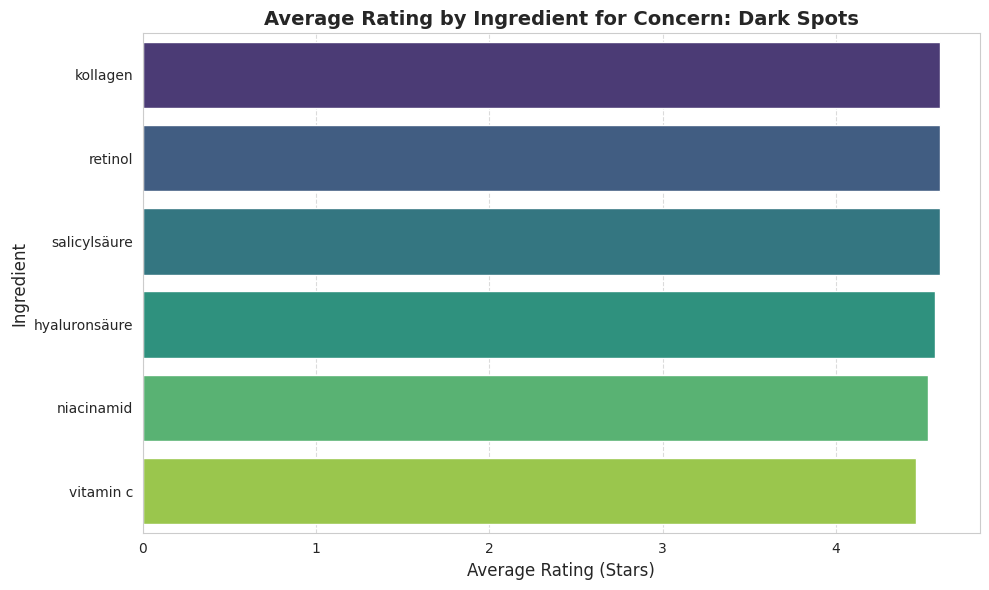



--- Concern: redness (Number of products: 3) ---


,Ingredient,Average Rating,Product Count
0,panthenol,4.8,1
1,bisabolol,4.8,1
2,niacinamid,4.2,1


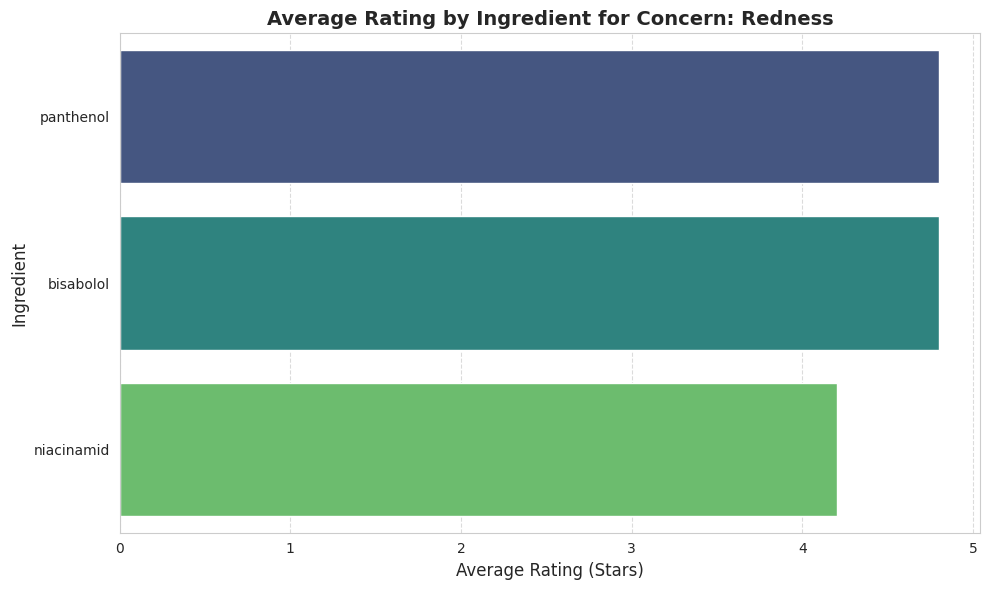



--- Concern: dehydrated (No matching products) ---

Analysis completed. Please check the rankings and average ratings of key ingredients for each skin concern.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

# df は既に読み込まれていると仮定

# 肌悩みフラグの列名リスト
concern_cols = [c for c in df.columns if c.startswith('concern_')]

# 検出したい主要な成分キーワードのリスト (小文字で正規化)
specific_ingredients_to_count = [
    'niacinamid', 'hyaluronsäure', 'vitamin c', 'retinol', 'kollagen',
    'glycerin', 'salicylsäure', 'panthenol', 'vitamin e', 'q10',
    'bisabolol', 'aloe vera', 'ginseng', 'retinal'
]

print("### Active Ingredient Analysis by Skin Concern\n")

# 各肌悩みについてループ
for col in concern_cols:
    concern_name = col.replace('concern_', '')

    # 該当する肌悩みの商品のみを抽出
    concern_subset_df = df[df[col] == 1].copy() # .copy() to avoid SettingWithCopyWarning

    if concern_subset_df.empty:
        print(f"--- Concern: {concern_name} (No matching products) ---\n")
        continue

    print(f"--- Concern: {concern_name} (Number of products: {len(concern_subset_df)}) ---")

    ingredient_stats_for_concern = []

    # 各成分キーワードについて、この肌悩みの商品内での統計を計算
    for keyword in specific_ingredients_to_count:
        # 正規表現で単語の境界を考慮してキーワードを検索
        # active_ingredient列がNoneやNaNの場合も考慮し、strに変換
        mask = concern_subset_df['active_ingredient'].astype(str).str.contains(
            r'\b' + re.escape(keyword) + r'\b', case=False, na=False
        )

        if mask.any():
            products_with_ingredient_in_concern = concern_subset_df[mask]
            avg_rating = products_with_ingredient_in_concern['rating'].mean()
            num_products = len(products_with_ingredient_in_concern)

            ingredient_stats_for_concern.append({
                'Ingredient': keyword,
                'Average Rating': round(avg_rating, 2),
                'Product Count': num_products
            })

    if not ingredient_stats_for_concern:
        print("  No major ingredients found.\n")
        continue

    df_concern_ingredients = pd.DataFrame(ingredient_stats_for_concern)
    # 平均評価の高い順にソート
    df_concern_ingredients = df_concern_ingredients.sort_values(by='Average Rating', ascending=False).reset_index(drop=True)

    display(df_concern_ingredients)

    # 可視化 (棒グラフ)
    plt.figure(figsize=(10, 6))
    sns.barplot(
        x='Average Rating',
        y='Ingredient',
        data=df_concern_ingredients,
        palette='viridis',
        hue='Ingredient', # 各成分を色分け
        legend=False
    )
    plt.title(f'Average Rating by Ingredient for Concern: {concern_name.replace("_", " ").title()}', fontsize=14, fontweight='bold')
    plt.xlabel('Average Rating (Stars)', fontsize=12)
    plt.ylabel('Ingredient', fontsize=12)
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
    print("\n" + "="*60 + "\n")

print("Analysis completed. Please check the rankings and average ratings of key ingredients for each skin concern.")

## 5. Brand Strategy & Best-Value Recommendations
- 5.1. Brand Ranking & Differentiators (Strengths by Concern/Ingredient)
- 5.2. Best Value Picks: Finding High-Rating & Low-Price Serums (コスパ最高商品)

### 5.1. Brand Ranking & Differentiators (Strengths by Concern/Ingredient)

高評価の製品に関するこれまでの分析を踏まえ、このカテゴリーで頻繁に見られるブランドについてさらに深く掘り下げ、対応する肌悩みや主要な有効成分といった観点​​から、それぞれの具体的な強みを理解していきましょう。

**高評価ブランドランキング**

評価が4.6以上の製品の中で、最も頻繁に登場するブランドを可視化

=== Brands in High-Rated Products (Rating >= 4.6) ===


,Brand,Product Count
0,L'ORÉAL PARiS,4
1,L'ORÉAL PARiS REVITALIFT,3
2,Mixa,2
3,Neutrogena,2
4,NIVEA,1
5,Garnier Skin Active,1
6,Beauty of Joseon,1
7,alverde NATURKOSMETIK,1


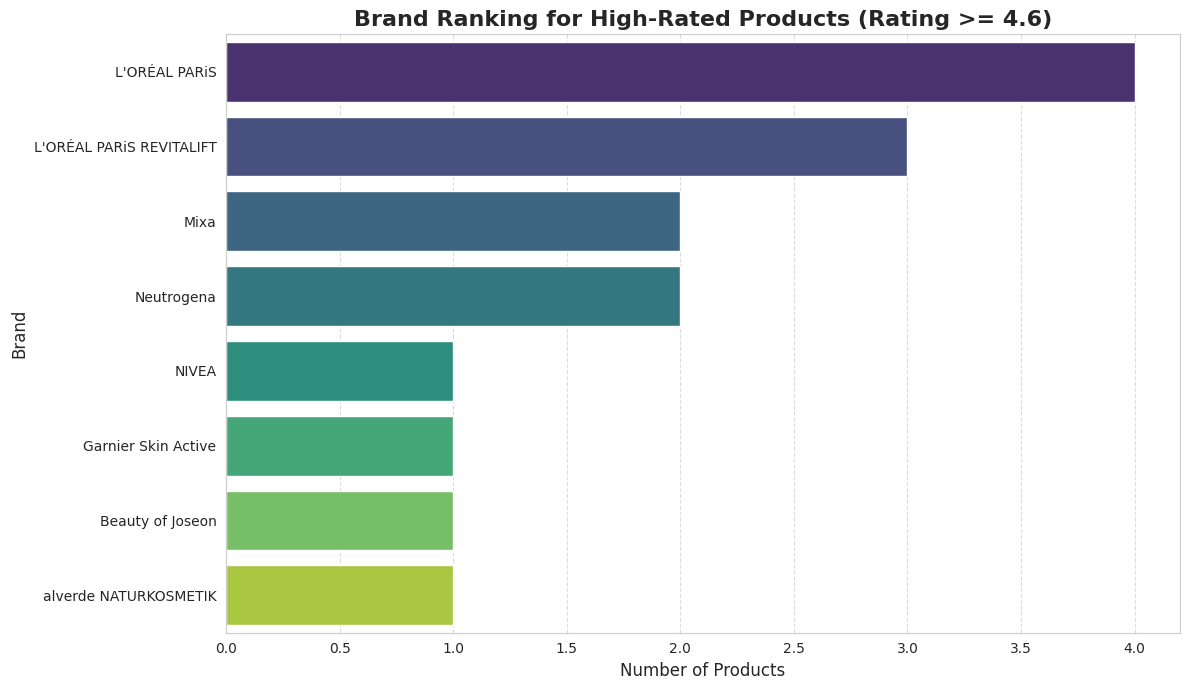

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter for high-rated products (rating >= 4.6)
high_rating_df = df[df['rating'] >= 4.6]

# Count the occurrences of each brand in the high-rated products
brand_rankings = high_rating_df['brand'].value_counts().reset_index()
brand_rankings.columns = ['Brand', 'Product Count']

# Display the ranking
print("=== Brands in High-Rated Products (Rating >= 4.6) ===")
display(brand_rankings)

# Create a bar chart for brand rankings
plt.figure(figsize=(12, 7))
sns.barplot(x='Product Count', y='Brand', data=brand_rankings, palette='viridis', hue='Brand', legend=False)
plt.title('Brand Ranking for High-Rated Products (Rating >= 4.6)', fontsize=16, fontweight='bold')
plt.xlabel('Number of Products', fontsize=12)
plt.ylabel('Brand', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**ブランド別平均評価と平均価格**

各ブランドの平均評価と100mlあたりの平均価格との関係を可視化し、潜在的なパターンを特定

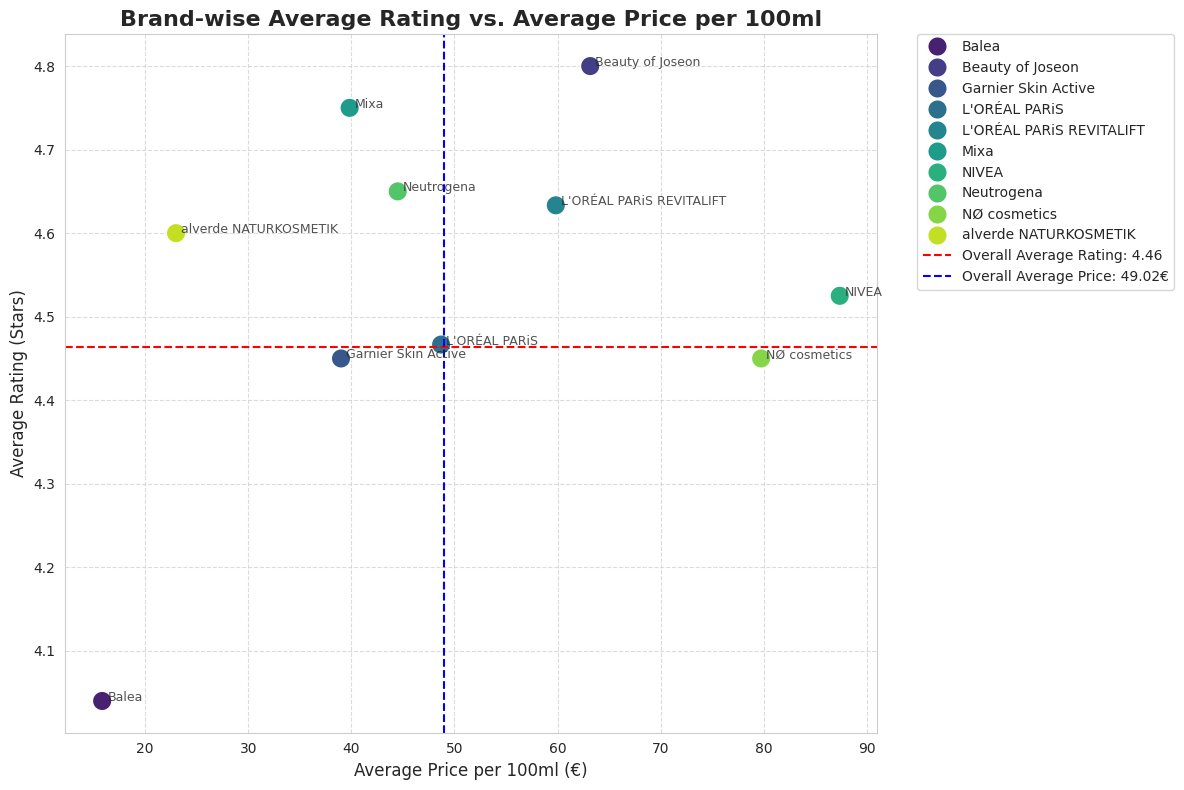

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Group by brand and calculate the average rating and average price per 100ml
df_brand_stats = df.groupby('brand').agg(
    avg_rating=('rating', 'mean'),
    avg_price_per_100ml=('price_per_100ml', 'mean')
).reset_index()

# Calculate overall average rating and price for context
overall_avg_rating = df['rating'].mean()
overall_avg_price = df['price_per_100ml'].mean()

plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=df_brand_stats,
    x='avg_price_per_100ml',
    y='avg_rating',
    hue='brand', # Color by brand
    s=200, # Marker size
    palette='viridis', # Color palette
    legend='full' # Show full legend
)

# Add brand names as labels to each point
for i, row in df_brand_stats.iterrows():
    plt.text(
        row['avg_price_per_100ml'] + 0.5, # X-coordinate with a slight offset
        row['avg_rating'], # Y-coordinate
        row['brand'], # Text label
        fontsize=9,
        alpha=0.8
    )

# Add overall average rating as a horizontal line
plt.axhline(y=overall_avg_rating, color='red', linestyle='--', label=f'Overall Average Rating: {overall_avg_rating:.2f}')
# Add overall average price as a vertical line
plt.axvline(x=overall_avg_price, color='blue', linestyle='--', label=f'Overall Average Price: {overall_avg_price:.2f}€')

plt.title('Brand-wise Average Rating vs. Average Price per 100ml', fontsize=16, fontweight='bold')
plt.xlabel('Average Price per 100ml (€)', fontsize=12)
plt.ylabel('Average Rating (Stars)', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.) # Place legend outside the plot
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**高評価ブランドの差別化要因（肌悩み・成分別の強み）**

Top3ブランド
- L'ORÉAL PARiS
- L'ORÉAL PARiS REVITALIFT
- Mixa

これらの高評価商品がターゲットとする肌悩み、含まれる成分を特定

=== Brand Strengths Analysis (High-Rated Products) ===


--- Analyzing Brand: L'ORÉAL PARiS ---
Number of high-rated products: 4

Top Concerns in High-Rated Products:
  - Anti Aging: 4 product(s)
  - Dark Spots: 2 product(s)
  - Sensitive: 2 product(s)

Top Active Ingredients in High-Rated Products:
  - Kollagen: 2 occurrence(s)
  - Vitamin C: 2 occurrence(s)
  - Glycerin: 1 occurrence(s)
  - Niacinamid: 1 occurrence(s)


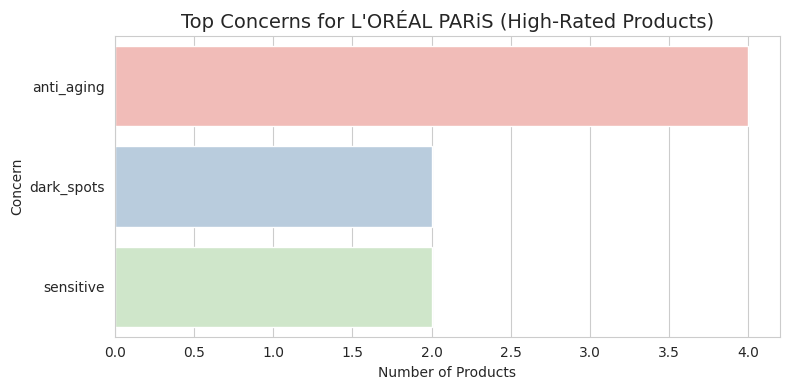

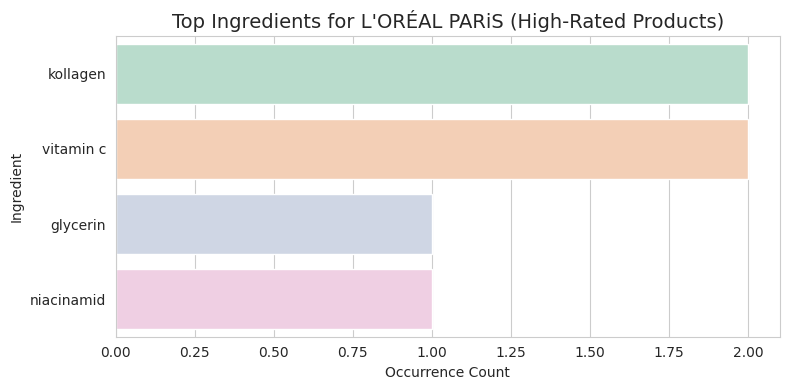


--- Analyzing Brand: L'ORÉAL PARiS REVITALIFT ---
Number of high-rated products: 3

Top Concerns in High-Rated Products:
  - Anti Aging: 3 product(s)
  - Sensitive: 1 product(s)
  - Dark Spots: 1 product(s)

Top Active Ingredients in High-Rated Products:
  - Vitamin C: 2 occurrence(s)
  - Salicylsäure: 1 occurrence(s)
  - Vitamin E: 1 occurrence(s)
  - Hyaluronsäure: 1 occurrence(s)
  - Retinol: 1 occurrence(s)


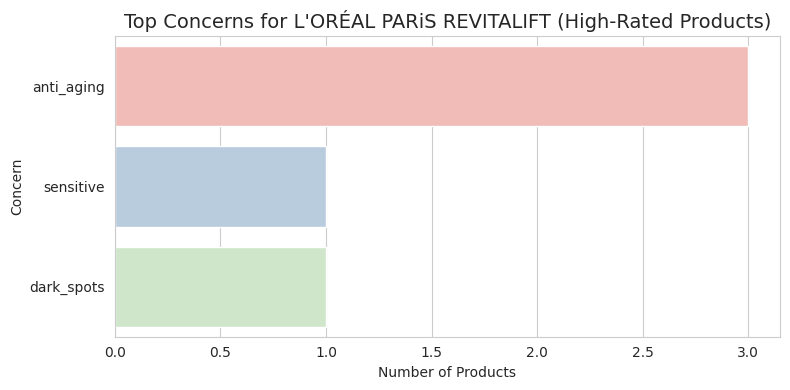

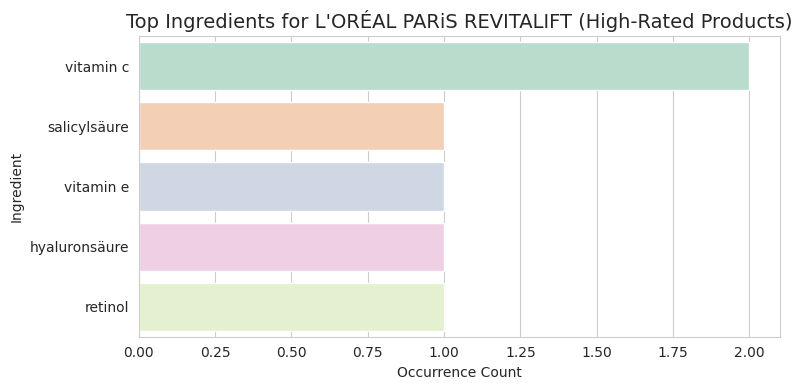


--- Analyzing Brand: Mixa ---
Number of high-rated products: 2

Top Concerns in High-Rated Products:
  - Sensitive: 1 product(s)
  - Redness: 1 product(s)
  - Acne: 1 product(s)
  - Dark Spots: 1 product(s)

Top Active Ingredients in High-Rated Products:
  - Panthenol: 1 occurrence(s)
  - Bisabolol: 1 occurrence(s)
  - Niacinamid: 1 occurrence(s)
  - Salicylsäure: 1 occurrence(s)


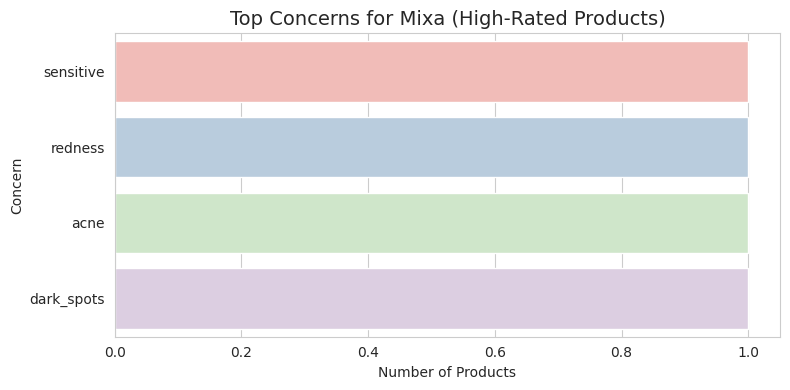

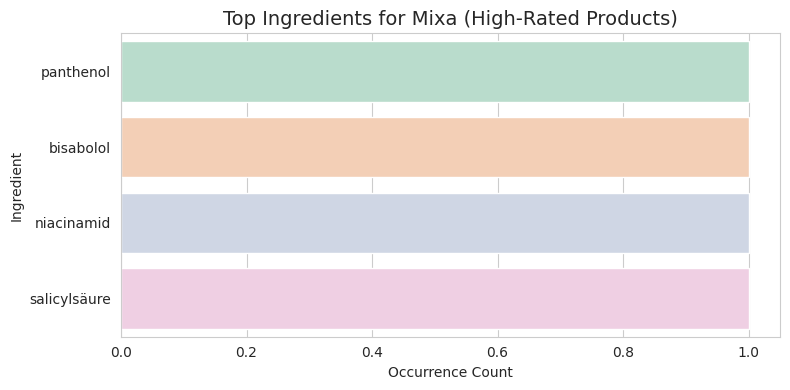


Analysis of brand strengths complete.


In [ ]:
import re
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Reuse lists from previous analysis
concern_cols = [c for c in df.columns if c.startswith('concern_')]
specific_ingredients_to_count = [
    'niacinamid', 'hyaluronsäure', 'vitamin c', 'retinol', 'kollagen',
    'glycerin', 'salicylsäure', 'panthenol', 'vitamin e', 'q10',
    'bisabolol', 'aloe vera', 'ginseng', 'retinal'
]

# Re-define high_rating_df and brand_rankings from previous cells (niBzfjZ1ODRR and c87433db)
# Assumes 'df' is already loaded in the environment or an earlier cell
high_rating_df = df[df['rating'] >= 4.6]
brand_rankings = high_rating_df['brand'].value_counts().reset_index()
brand_rankings.columns = ['Brand', 'Product Count']

# Get the top N brands from the brand_rankings (e.g., top 3 or 5)
top_brands_to_analyze = brand_rankings['Brand'].head(3).tolist() # Analyzing top 3 brands

print("=== Brand Strengths Analysis (High-Rated Products) ===\n")

for brand_name in top_brands_to_analyze:
    print(f"\n--- Analyzing Brand: {brand_name} ---")
    brand_high_rating_df = high_rating_df[high_rating_df['brand'] == brand_name].copy()

    if brand_high_rating_df.empty:
        print(f"No high-rated products found for {brand_name}.")
        continue

    print(f"Number of high-rated products: {len(brand_high_rating_df)}")

    # --- Analyze Skin Concerns for this Brand ---
    concern_counts = Counter()
    for _, row in brand_high_rating_df.iterrows():
        for col in concern_cols:
            if row[col] == 1:
                concern_counts[col.replace('concern_', '')] += 1

    print("\nTop Concerns in High-Rated Products:")
    if concern_counts:
        for concern, count in concern_counts.most_common():
            print(f"  - {concern.replace('_', ' ').title()}: {count} product(s)")
    else:
        print("  No specific concerns identified.")

    # --- Analyze Active Ingredients for this Brand ---
    ingredient_counts = Counter()
    for _, row in brand_high_rating_df.iterrows():
        active_ingredient_str = str(row['active_ingredient']).lower()
        if active_ingredient_str and active_ingredient_str != 'nan':
            for keyword in specific_ingredients_to_count:
                matches = re.findall(r'\b' + re.escape(keyword) + r'\b', active_ingredient_str)
                if matches:
                    ingredient_counts[keyword] += len(matches)

    print("\nTop Active Ingredients in High-Rated Products:")
    if ingredient_counts:
        for ingredient, count in ingredient_counts.most_common():
            print(f"  - {ingredient.replace('_', ' ').title()}: {count} occurrence(s)")
    else:
        print("  No specific active ingredients identified.")

    # Optional: Visualize top concerns/ingredients for each brand
    if concern_counts:
        df_concerns = pd.DataFrame(concern_counts.most_common(), columns=['Concern', 'Product Count'])
        plt.figure(figsize=(8, 4))
        sns.barplot(x='Product Count', y='Concern', data=df_concerns, palette='Pastel1', hue='Concern', legend=False)
        plt.title(f'Top Concerns for {brand_name} (High-Rated Products)', fontsize=14)
        plt.xlabel('Number of Products')
        plt.ylabel('Concern')
        plt.tight_layout()
        plt.show()

    if ingredient_counts:
        df_ingredients = pd.DataFrame(ingredient_counts.most_common(), columns=['Ingredient', 'Occurrence Count'])
        plt.figure(figsize=(8, 4))
        sns.barplot(x='Occurrence Count', y='Ingredient', data=df_ingredients, palette='Pastel2', hue='Ingredient', legend=False)
        plt.title(f'Top Ingredients for {brand_name} (High-Rated Products)', fontsize=14)
        plt.xlabel('Occurrence Count')
        plt.ylabel('Ingredient')
        plt.tight_layout()
        plt.show()

print("\nAnalysis of brand strengths complete.")

### 5.2. Best Value Picks: Finding High-Rating & Low-Price Serums

データセット全体の中で、最もコスパが良い（低価格かつ高評価）製品をリストアップします。ここでは、評価が4.6以上で、かつ100mlあたりの価格が全体の平均価格以下である製品を「コスパが良い」と定義します。

In [ ]:
# Calculate the overall average price per 100ml (if not already defined)
# overall_avg_price = df['price_per_100ml'].mean() # This should be available from cell 8ca3f98e

# Define the criteria for 'high rating' and 'low price'
high_rating_threshold = 4.6
low_price_threshold = overall_avg_price # Use the overall average price as the cutoff for 'low price'

# Filter for cost-effective products
cost_effective_products = df[
    (df['rating'] >= high_rating_threshold) &
    (df['price_per_100ml'] <= low_price_threshold)
]

# Sort by price (ascending) and then by rating (descending) to show the 'best' first
cost_effective_products = cost_effective_products.sort_values(
    by=['price_per_100ml', 'rating'],
    ascending=[True, False]
).reset_index(drop=True)

print(f"=== Products with Rating >= {high_rating_threshold} and Price <= {low_price_threshold:.2f}€/100ml ===")

if cost_effective_products.empty:
    print("No products found matching the criteria.")
else:
    # Display relevant columns
    display(cost_effective_products[[
        'brand', 'product', 'price_eur', 'volume_ml', 'price_per_100ml',
        'rating', 'number_of_reviews', 'product_type', 'active_ingredient'
    ]])

print("\nAnalysis of cost-effective products complete.")

=== Products with Rating >= 4.6 and Price <= 49.02€/100ml ===


,brand,product,price_eur,volume_ml,price_per_100ml,rating,number_of_reviews,product_type,active_ingredient
0,alverde NATURKOSMETIK,"Gesichtsöl Wildrose, 15 ml",3.45,15,23.00,4.6,330,Other Serum,"natürlichen Ölen, Apfelkern-Extrakt"
1,Mixa,"Serum Anti-Hautstress, 30 ml",9.95,30,33.17,4.8,2862,Barrier / Soothing Serum,"Panthenol, natürlichem Bisabolol"
2,L'ORÉAL PARiS,"Serum Anti Age Kollagen Experte, 30 ml",9.95,30,33.17,4.6,886,Anti-Aging / Retinol Serum,"Kollagen-Peptid-Fraktionen, Glycerin, Vitamin C"
3,Garnier Skin Active,"Serum Hyaluron Aloe Hydra Booster, 30 ml",9.95,30,33.17,4.6,386,Hyaluron / Hydration Serum,"Hyaluronsäure, Aloe vera"
4,Neutrogena,"Serum Hydro Boost Pures Hyaluron, 30 ml",11.75,30,39.17,4.7,413,Hyaluron / Hydration Serum,"Hyaluronsäure, Vitamin E"
5,L'ORÉAL PARiS,Anti Age Gesichtsserum Revitalift Laser Dreifa...,19.95,50,39.90,4.6,420,Anti-Aging / Retinol Serum,"Melasyl, Vitamin C, Niacinamid"
6,Mixa,"Serum Anti-Unreinheiten, Niacinamide, 30 ml",13.95,30,46.50,4.7,1029,Niacinamide Serum,"Salicylsäure, Niacinamid"
7,L'ORÉAL PARiS REVITALIFT,"Anti Age Fluid Revitalift Laser X3, 30 ml",13.95,30,46.50,4.6,312,Anti-Aging / Retinol Serum,Retinol



Analysis of cost-effective products complete.


**📊 考察の振り返りとビジネス的インサイト**

PB（プライベートブランド）の価格ポジショニング:

価格構造: PBの価格帯は極めて低い水準（中央値で20ユーロ以上の差）で狭く圧縮されています。これは「徹底した低価格・コストパフォーマンス」をブランドの核（Core Value）に置いているためです。

評価の差（中央値 4.1 vs 4.6）: レビュー数の多さではなく、「価格を極限まで下げるための処方・使用感の限界」や「手軽に買えるからこそ試す層の期待値の多様化」が評価に反映されている可能性が高いです。

NB（ナショナルブランド）の強み:

L'Oréal Paris 等の存在感: 高評価（★4.6以上）の半数を占める中でPBの割合がわずか6.7%（ほぼNBが独占）というのは強烈なデータです。

ブランド力と有効性: 特に Anti-Aging / Retinol やエイジングケア領域において、大手NBブランド（L'Oréal, NIVEA等）に対するユーザーの信頼度・使用感の満足度（テクスチャーや香り、実際の肌実感）が非常に高く維持されていることが裏付けられました。